#### Importing Required Libararies:

In [50]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay
)

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_validate
import time

#### Loading data and preprocessor:

In [37]:
X_train = joblib.load("../data/X_train.pkl")
X_test = joblib.load("../data/X_test.pkl")
y_train = joblib.load("../data/y_train.pkl")
y_test = joblib.load("../data/y_test.pkl")

preprocessor = joblib.load("../outputs/models/preprocessor.pkl")

# Application and Evaluation of different ML models:

I did that because it will prevent the repition of code.

#### Perform Cross Validation:

This function perform cross-validation on the training data.

In [38]:
def perform_cross_validation(pipeline, X_train, y_train):

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    cv_results = cross_validate(
        estimator=pipeline,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=[
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc"
        ],
        n_jobs=-1,
        return_train_score=False
    )

    cv_results_df = pd.DataFrame(cv_results)

    cv_results_df = cv_results_df.drop(
        columns=["fit_time", "score_time"]
    )

    return cv_results_df

#### Print Fold-wise Results:

This fuction print fold-wise cross-validation results.

In [22]:
def print_cv_fold_results(cv_results):
    df = pd.DataFrame({
        "Fold": range(1, len(cv_results["test_accuracy"]) + 1),
        "Accuracy": cv_results["test_accuracy"],
        "Precision": cv_results["test_precision"],
        "Recall": cv_results["test_recall"],
        "F1 Score": cv_results["test_f1"],
        "ROC AUC": cv_results["test_roc_auc"]
    })

    return df

#### Print Average Cross Validation Results:

Print average cross-validation metrics.

In [23]:
def print_cv_average_results(cv_results):
    cv_df = pd.DataFrame(cv_results)

    print(f"Accuracy  : {cv_df['test_accuracy'].mean():.4f}")
    print(f"Precision : {cv_df['test_precision'].mean():.4f}")
    print(f"Recall    : {cv_df['test_recall'].mean():.4f}")
    print(f"F1 Score  : {cv_df['test_f1'].mean():.4f}")
    print(f"ROC AUC   : {cv_df['test_roc_auc'].mean():.4f}")

#### Print Standard Deviation:

Print the standard deviation of cross-validation metrics.

In [24]:
def print_cv_standard_deviation(cv_results):

    cv_df = pd.DataFrame(cv_results)


    print(f"Accuracy  : {cv_df['test_accuracy'].std():.4f}")
    print(f"Precision : {cv_df['test_precision'].std():.4f}")
    print(f"Recall    : {cv_df['test_recall'].std():.4f}")
    print(f"F1 Score  : {cv_df['test_f1'].std():.4f}")
    print(f"ROC AUC   : {cv_df['test_roc_auc'].std():.4f}")

#### Fit Pipeline:

This function train the pipeline and record training time.

In [25]:
def fit_pipeline(pipeline, X_train, y_train):
    start_time = time.perf_counter()
    pipeline.fit(X_train, y_train)
    training_time = time.perf_counter() - start_time
    
    return pipeline, training_time

#### Predict:

This function generate predictions on both training and test sets.

In [26]:
def predict_pipeline(pipeline, X_train, X_test):

    train_predictions = pipeline.predict(X_train)
    test_predictions = pipeline.predict(X_test)

    if hasattr(pipeline, "predict_proba"):

        train_probabilities = pipeline.predict_proba(X_train)[:, 1]
        test_probabilities = pipeline.predict_proba(X_test)[:, 1]

    else:

        train_probabilities = None
        test_probabilities = None

    return (
        train_predictions,
        test_predictions,
        train_probabilities,
        test_probabilities
    )

#### Print Test Metrics:

In [27]:
def print_test_metrics(y_test, test_predictions, test_probabilities):

    accuracy = accuracy_score(y_test, test_predictions)
    precision = precision_score(y_test, test_predictions)
    recall = recall_score(y_test, test_predictions)
    f1 = f1_score(y_test, test_predictions)

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    metrics = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

    if test_probabilities is not None:
        roc_auc = roc_auc_score(y_test, test_probabilities)

        print(f"ROC AUC   : {roc_auc:.4f}")

        metrics["ROC AUC"] = roc_auc

    return metrics

#### Print Confusion Matrix:

This fuction plots confusion matrix.

In [28]:
def print_confusion_matrix(y_test, test_predictions, model_name):
    
    ConfusionMatrixDisplay.from_predictions(y_test, test_predictions)

    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

#### Plot ROC Curve:

This function plot ROC curve if probabilities are available.

In [29]:
def plot_roc_curve(
    y_test,
    test_probabilities,
    model_name
):
    if test_probabilities is None:
        print(f"ROC curve is not available for {model_name}.")
        return

    RocCurveDisplay.from_predictions(
        y_test,
        test_probabilities
    )

    plt.title(f"{model_name} - ROC Curve")
    plt.show()

#### Compare Train vs Test Performance:

Compare training and test performance to check for overfitting.

In [30]:
def compare_train_vs_test(y_train, train_predictions, y_test, test_predictions):

    # Training metrics
    train_accuracy = accuracy_score(y_train, train_predictions)
    train_precision = precision_score(y_train, train_predictions)
    train_recall = recall_score(y_train, train_predictions)
    train_f1 = f1_score(y_train, train_predictions)

    # Test metrics
    test_accuracy = accuracy_score(y_test, test_predictions)
    test_precision = precision_score(y_test, test_predictions)
    test_recall = recall_score(y_test, test_predictions)
    test_f1 = f1_score(y_test, test_predictions)

    comparison_df = pd.DataFrame({
        "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
        "Training": [
            train_accuracy,
            train_precision,
            train_recall,
            train_f1
        ],
        "Test": [
            test_accuracy,
            test_precision,
            test_recall,
            test_f1
        ]
    })

    comparison_df["Difference"] = abs(
        comparison_df["Training"] - comparison_df["Test"]
    )

    comparison_df[["Training", "Test", "Difference"]] = comparison_df[
        ["Training", "Test", "Difference"]
    ].round(4)

    return comparison_df

### 1. Random Forest:

In [31]:
random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", RandomForestClassifier(
        random_state=42
    ))
])

##### Perform Cross Validation:

In [32]:
cv_results = perform_cross_validation(
    pipeline=random_forest_pipeline,
    X_train=X_train,
    y_train=y_train
)

NameError: name 'StratifiedKFold' is not defined

##### Print Fold-wise CV Results:

In [ ]:
print_cv_fold_results(cv_results)

#####  Print Average CV Results:

In [ ]:
print_cv_average_results(cv_results)

##### Print Standard Deviation:

In [ ]:
print_cv_standard_deviation(cv_results)

##### Train the Pipeline:

In [ ]:
trained_pipeline, training_time = fit_pipeline(
    pipeline=random_forest_pipeline,
    X_train=X_train,
    y_train=y_train
)

print(f"\nTraining Time: {training_time:.4f} seconds")

##### Make Predictions:

In [ ]:
(
    train_predictions,
    test_predictions,
    train_probabilities,
    test_probabilities
) = predict_pipeline(
    pipeline=trained_pipeline,
    X_train=X_train,
    X_test=X_test
)

##### Print Test Metrics:

In [ ]:
metrics = print_test_metrics(
    y_test=y_test,
    test_predictions=test_predictions,
    test_probabilities=test_probabilities
)

##### Print Confusion Matrix:

In [ ]:
print_confusion_matrix(
    y_test=y_test,
    test_predictions=test_predictions,
    model_name="Random Forest"
)

##### Plot ROC Curve:

In [ ]:
plot_roc_curve(
    y_test=y_test,
    test_probabilities=test_probabilities,
    model_name="Random Forest"
)

##### Compare Training and Test Performance:

In [ ]:
compare_train_vs_test(
    y_train=y_train,
    train_predictions=train_predictions,
    y_test=y_test,
    test_predictions=test_predictions
)

### 2. Logistic Regression:

In [ ]:
logistic_regression_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [ ]:
cv_results = perform_cross_validation(
    pipeline=logistic_regression_pipeline ,
    X_train=X_train,
    y_train=y_train
)

In [ ]:
print_cv_fold_results(cv_results)

In [ ]:
print_cv_average_results(cv_results)

In [ ]:
print_cv_standard_deviation(cv_results)

In [ ]:
trained_pipeline, training_time = fit_pipeline(
    pipeline=logistic_regression_pipeline,
    X_train=X_train,
    y_train=y_train
)

print(f"\nTraining Time: {training_time:.4f} seconds")


In [ ]:
(
    train_predictions,
    test_predictions,
    train_probabilities,
    test_probabilities
) = predict_pipeline(
    pipeline=trained_pipeline,
    X_train=X_train,
    X_test=X_test
)

In [ ]:
metrics = print_test_metrics(
    y_test=y_test,
    test_predictions=test_predictions,
    test_probabilities=test_probabilities
)


In [ ]:
print_confusion_matrix(
    y_test=y_test,
    test_predictions=test_predictions,
    model_name="Logistic Regression"
)

In [ ]:
plot_roc_curve(
    y_test=y_test,
    test_probabilities=test_probabilities,
    model_name="Logistic Regression"
)

In [ ]:
compare_train_vs_test(
    y_train=y_train,
    train_predictions=train_predictions,
    y_test=y_test,
    test_predictions=test_predictions
)

### 3. Decision Tree:

In [ ]:
decision_tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", DecisionTreeClassifier(
        random_state=42
    ))
])

In [ ]:
cv_results = perform_cross_validation(
    pipeline=decision_tree_pipeline,
    X_train=X_train,
    y_train=y_train
)

In [ ]:
print_cv_fold_results(cv_results)

In [ ]:
print_cv_average_results(cv_results)

In [ ]:
print_cv_standard_deviation(cv_results)

In [ ]:
trained_pipeline, training_time = fit_pipeline(
    pipeline=decision_tree_pipeline,
    X_train=X_train,
    y_train=y_train
)

print(f"Training Time: {training_time:.4f} seconds")

In [ ]:
(
    train_predictions,
    test_predictions,
    train_probabilities,
    test_probabilities
) = predict_pipeline(
    pipeline=trained_pipeline,
    X_train=X_train,
    X_test=X_test
)

In [ ]:
_ = print_test_metrics(
    y_test=y_test,
    test_predictions=test_predictions,
    test_probabilities=test_probabilities
)

In [ ]:
print_confusion_matrix(
    y_test=y_test,
    test_predictions=test_predictions,
    model_name="Decision Tree"
)

In [ ]:
plot_roc_curve(
    y_test=y_test,
    test_probabilities=test_probabilities,
    model_name="Decision Tree"
)

In [ ]:
comparison_df = compare_train_vs_test(
    y_train=y_train,
    train_predictions=train_predictions,
    y_test=y_test,
    test_predictions=test_predictions
)

comparison_df

### 4. XgBoost:

In [ ]:
xgboost_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

In [ ]:
cv_results = perform_cross_validation(
    pipeline=xgboost_pipeline,
    X_train=X_train,
    y_train=y_train
)

In [ ]:
print_cv_fold_results(cv_results)

In [ ]:
print_cv_average_results(cv_results)

In [ ]:
print_cv_standard_deviation(cv_results)

In [ ]:
trained_pipeline, training_time = fit_pipeline(
    pipeline=xgboost_pipeline,
    X_train=X_train,
    y_train=y_train
)

print(f"Training Time: {training_time:.4f} seconds")

In [ ]:
(
    train_predictions,
    test_predictions,
    train_probabilities,
    test_probabilities
) = predict_pipeline(
    pipeline=trained_pipeline,
    X_train=X_train,
    X_test=X_test
)

In [ ]:
_ = print_test_metrics(
    y_test=y_test,
    test_predictions=test_predictions,
    test_probabilities=test_probabilities
)

In [ ]:
print_confusion_matrix(
    y_test=y_test,
    test_predictions=test_predictions,
    model_name="XGBoost"
)

In [ ]:
plot_roc_curve(
    y_test=y_test,
    test_probabilities=test_probabilities,
    model_name="XGBoost"
)

In [ ]:
comparison_df = compare_train_vs_test(
    y_train=y_train,
    train_predictions=train_predictions,
    y_test=y_test,
    test_predictions=test_predictions
)

comparison_df

### 5. Gradient Boosting:

In [ ]:
gradient_boosting_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", GradientBoostingClassifier(
        random_state=42
    ))
])

In [41]:
cv_results = perform_cross_validation(
    pipeline=gradient_boosting_pipeline,
    X_train=X_train,
    y_train=y_train
)

In [42]:
print_cv_fold_results(cv_results)

,Fold,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,1,0.989011,0.983051,1.000000,0.991453,0.998433
1,2,0.956044,0.949153,0.982456,0.965517,0.980908
2,3,0.923077,0.980769,0.894737,0.935780,0.991744
3,4,0.934066,0.963636,0.929825,0.946429,0.987100
4,5,1.000000,1.000000,1.000000,1.000000,1.000000


In [43]:
print_cv_average_results(cv_results)

Accuracy  : 0.9604
Precision : 0.9753
Recall    : 0.9614
F1 Score  : 0.9678
ROC AUC   : 0.9916


In [45]:
trained_pipeline, training_time = fit_pipeline(
    pipeline=gradient_boosting_pipeline,
    X_train=X_train,
    y_train=y_train
)

print(f"Training Time: {training_time:.4f} seconds")

Training Time: 0.9111 seconds


In [46]:
(
    train_predictions,
    test_predictions,
    train_probabilities,
    test_probabilities
) = predict_pipeline(
    pipeline=trained_pipeline,
    X_train=X_train,
    X_test=X_test
)

In [48]:
_ = print_test_metrics(
    y_test=y_test,
    test_predictions=test_predictions,
    test_probabilities=test_probabilities
)

Accuracy  : 0.9649
Precision : 0.9718
Recall    : 0.9718
F1 Score  : 0.9718
ROC AUC   : 0.9971


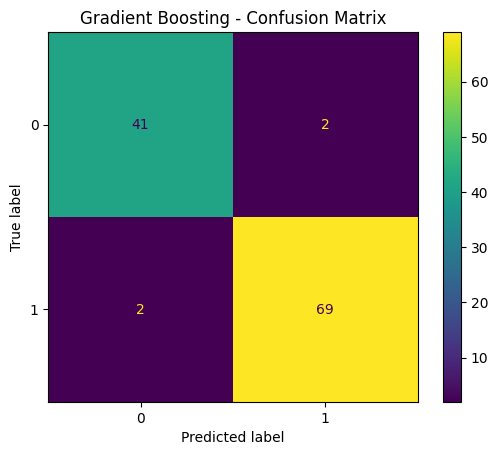

In [51]:
print_confusion_matrix(
    y_test=y_test,
    test_predictions=test_predictions,
    model_name="Gradient Boosting"
)

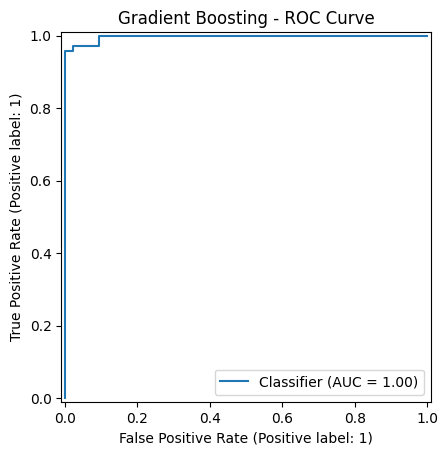

In [52]:
plot_roc_curve(
    y_test=y_test,
    test_probabilities=test_probabilities,
    model_name="Gradient Boosting"
)

In [55]:
comparison_df = compare_train_vs_test(
    y_train=y_train,
    train_predictions=train_predictions,
    y_test=y_test,
    test_predictions=test_predictions
)

comparison_df

,Metric,Training,Test,Difference
0,Accuracy,1.0,0.9649,0.0351
1,Precision,1.0,0.9718,0.0282
2,Recall,1.0,0.9718,0.0282
3,F1 Score,1.0,0.9718,0.0282


### 6. Support Vector Machine(SVM):

In [65]:
svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", SVC(
        probability=True,
        random_state=42
    ))
])

In [67]:
cv_results = perform_cross_validation(
    pipeline=gradient_boosting_pipeline,
    X_train=X_train,
    y_train=y_train
)

In [68]:
print_cv_fold_results(cv_results)

,Fold,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,1,0.989011,0.983051,1.000000,0.991453,0.998433
1,2,0.956044,0.949153,0.982456,0.965517,0.980908
2,3,0.923077,0.980769,0.894737,0.935780,0.991744
3,4,0.934066,0.963636,0.929825,0.946429,0.987100
4,5,1.000000,1.000000,1.000000,1.000000,1.000000


In [69]:
print_cv_average_results(cv_results)

Accuracy  : 0.9604
Precision : 0.9753
Recall    : 0.9614
F1 Score  : 0.9678
ROC AUC   : 0.9916


In [70]:
print_cv_standard_deviation(cv_results)

Accuracy  : 0.0335
Precision : 0.0195
Recall    : 0.0471
F1 Score  : 0.0278
ROC AUC   : 0.0079


In [72]:
trained_pipeline, training_time = fit_pipeline(
    pipeline=svm_pipeline,
    X_train=X_train,
    y_train=y_train
)

print(f"Training Time: {training_time:.4f} seconds")

Training Time: 0.0595 seconds


In [73]:
(
    train_predictions,
    test_predictions,
    train_probabilities,
    test_probabilities
) = predict_pipeline(
    pipeline=trained_pipeline,
    X_train=X_train,
    X_test=X_test
)

In [75]:
_= print_test_metrics(
    y_test=y_test,
    test_predictions=test_predictions,
    test_probabilities=test_probabilities
)

Accuracy  : 0.9737
Precision : 0.9722
Recall    : 0.9859
F1 Score  : 0.9790
ROC AUC   : 0.9971


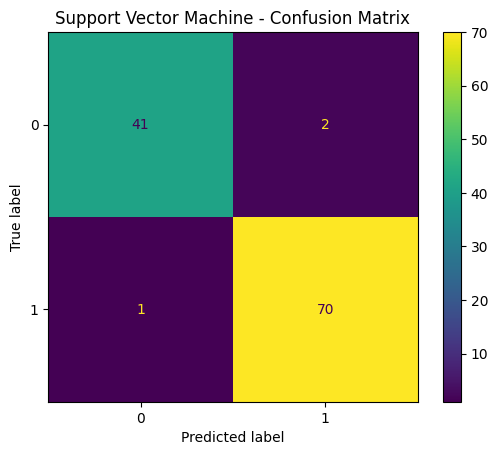

In [76]:
print_confusion_matrix(
    y_test=y_test,
    test_predictions=test_predictions,
    model_name="Support Vector Machine"
)

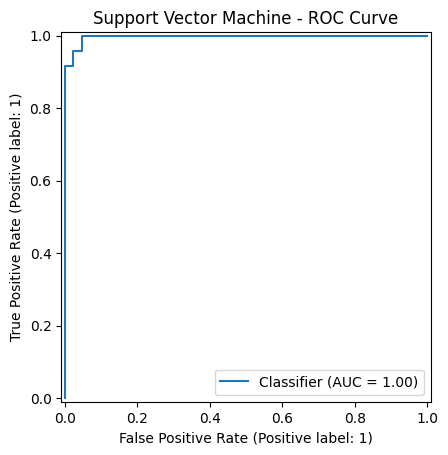

In [77]:
plot_roc_curve(
    y_test=y_test,
    test_probabilities=test_probabilities,
    model_name="Support Vector Machine"
)

In [78]:
comparison_df = compare_train_vs_test(
    y_train=y_train,
    train_predictions=train_predictions,
    y_test=y_test,
    test_predictions=test_predictions
)

comparison_df

,Metric,Training,Test,Difference
0,Accuracy,0.9846,0.9737,0.0109
1,Precision,0.9827,0.9722,0.0105
2,Recall,0.9930,0.9859,0.0071
3,F1 Score,0.9878,0.9790,0.0088


### 7. KNN 

In [89]:
knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", KNeighborsClassifier(
        n_neighbors=5
    ))
])

In [90]:
cv_results = perform_cross_validation(
    pipeline=knn_pipeline,
    X_train=X_train,
    y_train=y_train
)

In [91]:
print_cv_fold_results(cv_results)

,Fold,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,1,0.967033,0.966102,0.982759,0.974359,0.997388
1,2,0.956044,0.949153,0.982456,0.965517,0.981682
2,3,0.967033,0.982143,0.964912,0.973451,0.993808
3,4,0.967033,0.965517,0.982456,0.973913,0.980392
4,5,0.934066,0.932203,0.964912,0.948276,0.994582


In [92]:
print_cv_average_results(cv_results)

Accuracy  : 0.9582
Precision : 0.9590
Recall    : 0.9755
F1 Score  : 0.9671
ROC AUC   : 0.9896


In [93]:
print_cv_standard_deviation(cv_results)

Accuracy  : 0.0143
Precision : 0.0190
Recall    : 0.0097
F1 Score  : 0.0111
ROC AUC   : 0.0079


In [94]:
print_cv_standard_deviation(cv_results)

Accuracy  : 0.0143
Precision : 0.0190
Recall    : 0.0097
F1 Score  : 0.0111
ROC AUC   : 0.0079


In [96]:
trained_pipeline, training_time = fit_pipeline(
    pipeline=knn_pipeline,
    X_train=X_train,
    y_train=y_train
)

print(f"Training Time: {training_time:.4f} seconds")

Training Time: 0.0187 seconds


In [97]:
(
    train_predictions,
    test_predictions,
    train_probabilities,
    test_probabilities
) = predict_pipeline(
    pipeline=trained_pipeline,
    X_train=X_train,
    X_test=X_test
)

In [99]:
_ = print_test_metrics(
    y_test=y_test,
    test_predictions=test_predictions,
    test_probabilities=test_probabilities
)

Accuracy  : 0.9561
Precision : 0.9714
Recall    : 0.9577
F1 Score  : 0.9645
ROC AUC   : 0.9759


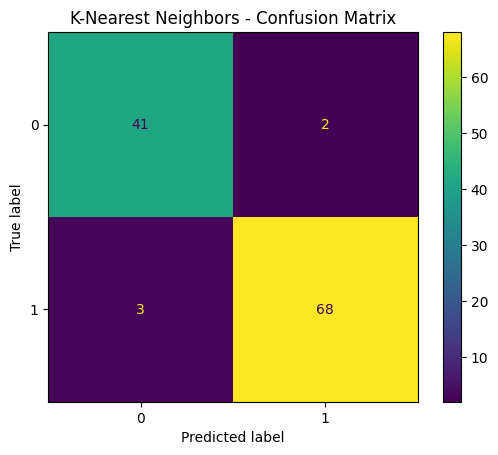

In [100]:
print_confusion_matrix(
    y_test=y_test,
    test_predictions=test_predictions,
    model_name="K-Nearest Neighbors"
)

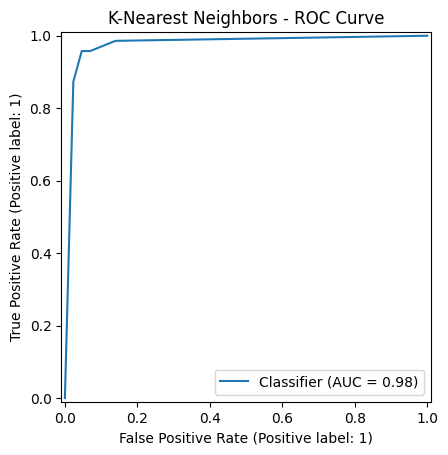

In [101]:
plot_roc_curve(
    y_test=y_test,
    test_probabilities=test_probabilities,
    model_name="K-Nearest Neighbors"
)

In [102]:
comparison_df = compare_train_vs_test(
    y_train=y_train,
    train_predictions=train_predictions,
    y_test=y_test,
    test_predictions=test_predictions
)

comparison_df

,Metric,Training,Test,Difference
0,Accuracy,0.9846,0.9561,0.0285
1,Precision,0.9827,0.9714,0.0113
2,Recall,0.9930,0.9577,0.0353
3,F1 Score,0.9878,0.9645,0.0233
